#  Text Summarization Project

**Extractive & Abstractive Approaches with Full Evaluation Pipeline**

This project implements two complementary summarization strategies:
-  **TF-IDF Extractive** — selects the most informative original sentences
-  **BART Abstractive** — generates fluent, novel summaries using a pre-trained transformer
-  **Full Evaluation** — ROUGE metrics and classification analysis
-  **Visualizations** — charts at every stage of the pipeline


---

##  Part 1 — Setup & Environment


### 1.0 — Dependency Installation

Install PyTorch **before** importing `transformers`. A CPU-only build is used here for broad compatibility across environments.




In [1]:
import subprocess, sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "torch", "torchvision", "torchaudio",
    "--index-url", "https://download.pytorch.org/whl/cpu",
    "--quiet"
])

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "transformers", "scikit-learn", "nltk", "pandas", "numpy",
    "matplotlib", "seaborn", "rouge-score",
    "--quiet"
])

0

### 1.1 — Environment Verification

Confirm PyTorch was installed correctly before importing anything else


In [2]:
try:
    import torch
    print(f"PyTorch version : {torch.__version__}")
    print(f"CUDA available  : {torch.cuda.is_available()}  (False is expected on CPU-only builds)")
except ImportError:
    raise ImportError(
        "PyTorch not found. Run cell 1.0 first, restart the kernel, then re-run from this cell."
    )

PyTorch version : 2.11.0+cpu
CUDA available  : False  (False is expected on CPU-only builds)


### 1.2 — Library Imports

Import the full scientific and NLP stack, configure the plotting theme, and download any missing NLTK data packages.


In [3]:
import re
import warnings
import numpy as np
import pandas as pd

import torch
import nltk
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from transformers import BartTokenizer, BartForConditionalGeneration

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from rouge_score import rouge_scorer

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#1a1a2e',
    'axes.edgecolor'   : '#444',
    'axes.labelcolor'  : '#ccc',
    'xtick.color'      : '#ccc',
    'ytick.color'      : '#ccc',
    'text.color'       : '#ccc',
    'grid.color'       : '#333',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
})

for pkg, path in [("punkt",     "tokenizers/punkt"),
                  ("punkt_tab", "tokenizers/punkt_tab"),
                  ("stopwords", "corpora/stopwords")]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(pkg, quiet=True)

STOP_WORDS = set(stopwords.words('english'))
print("All libraries imported successfully.")

c:\Users\shahd\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully.


---

##  Part 2 — Data Loading & Exploratory Analysis


### 2.1 — Data Loading

Load a sample of 50,000 records from `data.csv`. This keeps memory usage manageable during development while still providing a representative dataset.


In [4]:
SAMPLE_SIZE = 50_000
DATA_PATH   = 'data.csv'

raw_df = pd.read_csv(DATA_PATH, nrows=SAMPLE_SIZE)
df     = raw_df[['Content', 'Summary']].copy()

print(f"Loaded  : {len(df):,} records")
print(f"Columns : {df.columns.tolist()}")
print(f"Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head(3)

Loaded  : 50,000 records
Columns : ['Content', 'Summary']
Memory  : 325.1 MB


,Content,Summary
0,New York police are concerned drones could bec...,Police have investigated criminals who have ri...
1,By . Ryan Lipman . Perhaps Australian porn sta...,Porn star Angela White secretly filmed sex act...
2,"This was, Sergio Garcia conceded, much like be...",American draws inspiration from fellow country...


### 2.2 — Dataset Overview

Print basic statistics: record counts, missing values, and column-level descriptive summaries for both `Content` and `Summary`.


In [5]:
print("=" * 55)
print("  DATASET SUMMARY")
print("=" * 55)
print(f"  Total records     : {len(df):,}")
print(f"  Null Content      : {df['Content'].isna().sum():,}")
print(f"  Null Summary      : {df['Summary'].isna().sum():,}")
print(f"  Duplicate Content : {df.duplicated(subset='Content').sum():,}")
print("=" * 55)

print("\n--- Content Column ---")
print(df['Content'].describe())

print("\n--- Summary Column ---")
print(df['Summary'].describe())

  DATASET SUMMARY
  Total records     : 50,000
  Null Content      : 3
  Null Summary      : 0
  Duplicate Content : 1,056

--- Content Column ---
count                                                 49997
unique                                                48943
top       WASHINGTON (CNN) -- President Bush condemned t...
freq                                                      3
Name: Content, dtype: object

--- Summary Column ---
count                                                 50000
unique                                                48870
top       This page includes the show Transcript, the Da...
freq                                                     10
Name: Summary, dtype: object


### 2.3 — Raw Data Visualizations

Explore the distribution of text lengths, summary lengths, and lexical diversity **before** any preprocessing is applied. This gives us a baseline to compare against later.


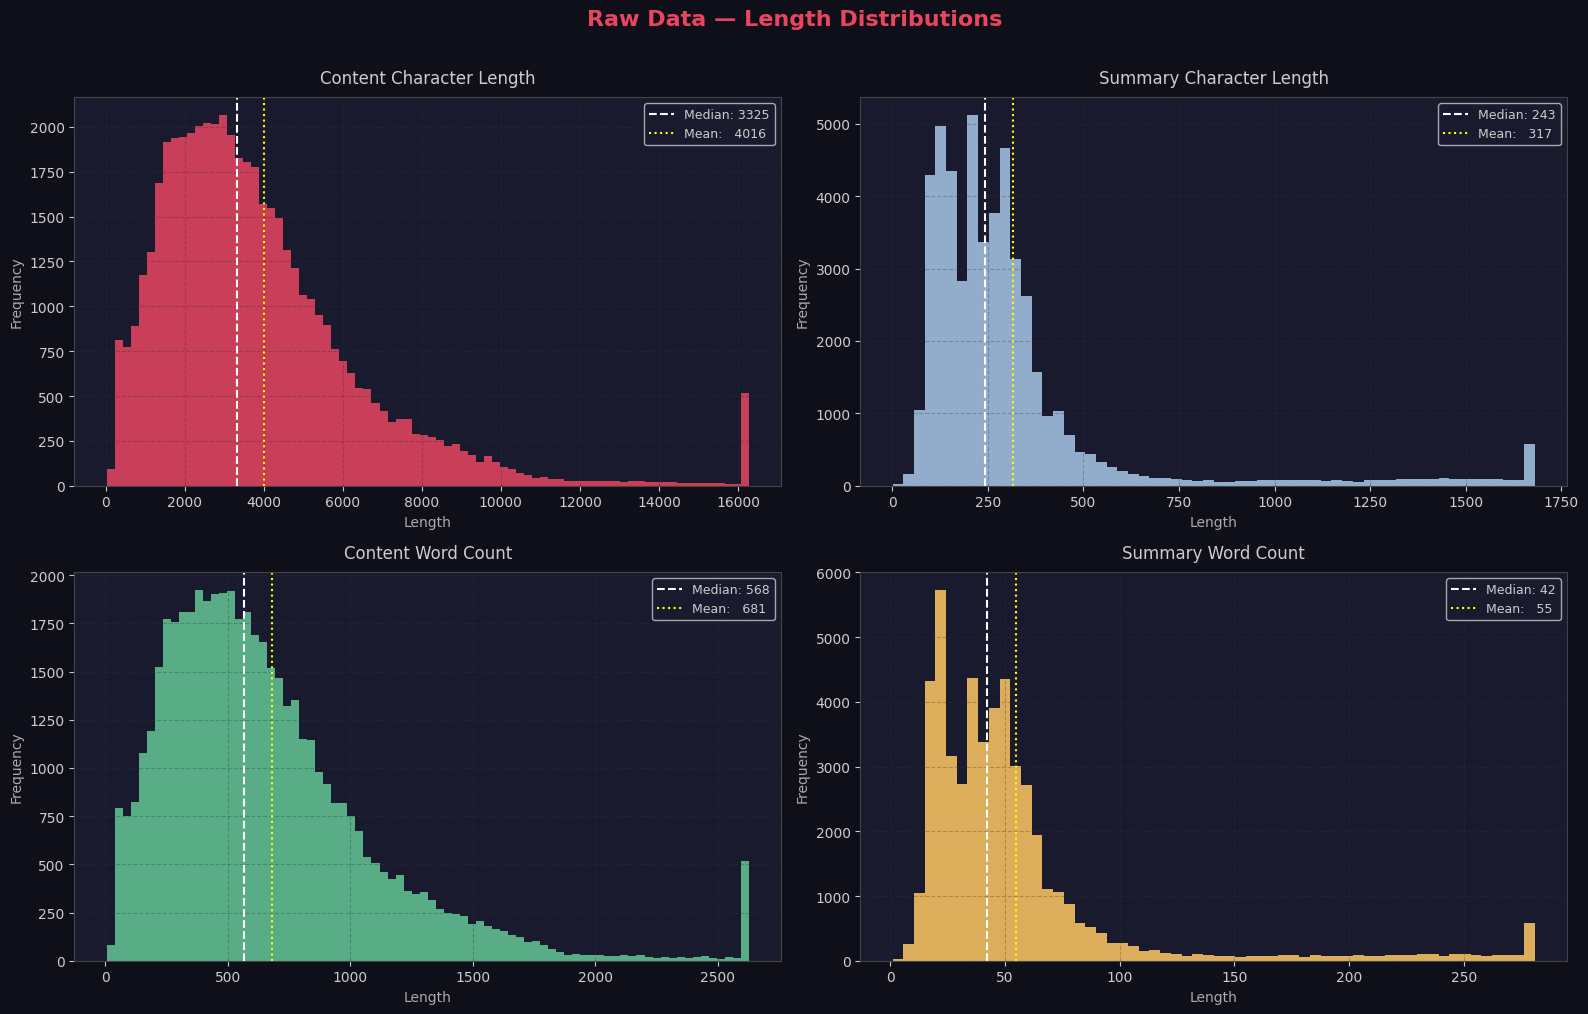

Figure 1 saved.


In [6]:
df['content_char_len']  = df['Content'].str.len()
df['summary_char_len']  = df['Summary'].str.len()
df['content_word_cnt']  = df['Content'].str.split().str.len()
df['summary_word_cnt']  = df['Summary'].str.split().str.len()
df['compression_ratio'] = (df['summary_char_len'] / df['content_char_len']).round(4)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Raw Data — Length Distributions', fontsize=16, color='#e94560', fontweight='bold', y=1.01)

ACCENT = ['#e94560', '#a8c8e8', '#64c896', '#ffc864']

plots = [
    (axes[0, 0], df['content_char_len'], ACCENT[0], 'Content Character Length', 80),
    (axes[0, 1], df['summary_char_len'],  ACCENT[1], 'Summary Character Length', 60),
    (axes[1, 0], df['content_word_cnt'],  ACCENT[2], 'Content Word Count',       80),
    (axes[1, 1], df['summary_word_cnt'],  ACCENT[3], 'Summary Word Count',        60),
]

for ax, series, color, title, bins in plots:
    clipped = series.clip(upper=series.quantile(0.99))
    ax.hist(clipped, bins=bins, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(series.median(), color='white', linestyle='--', linewidth=1.5, label=f'Median: {series.median():.0f}')
    ax.axvline(series.mean(),   color='yellow', linestyle=':',  linewidth=1.5, label=f'Mean:   {series.mean():.0f}')
    ax.set_title(title, color='#ccc', fontsize=12, pad=10)
    ax.set_xlabel('Length', color='#aaa')
    ax.set_ylabel('Frequency', color='#aaa')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_length_distributions.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Figure 1 saved.")

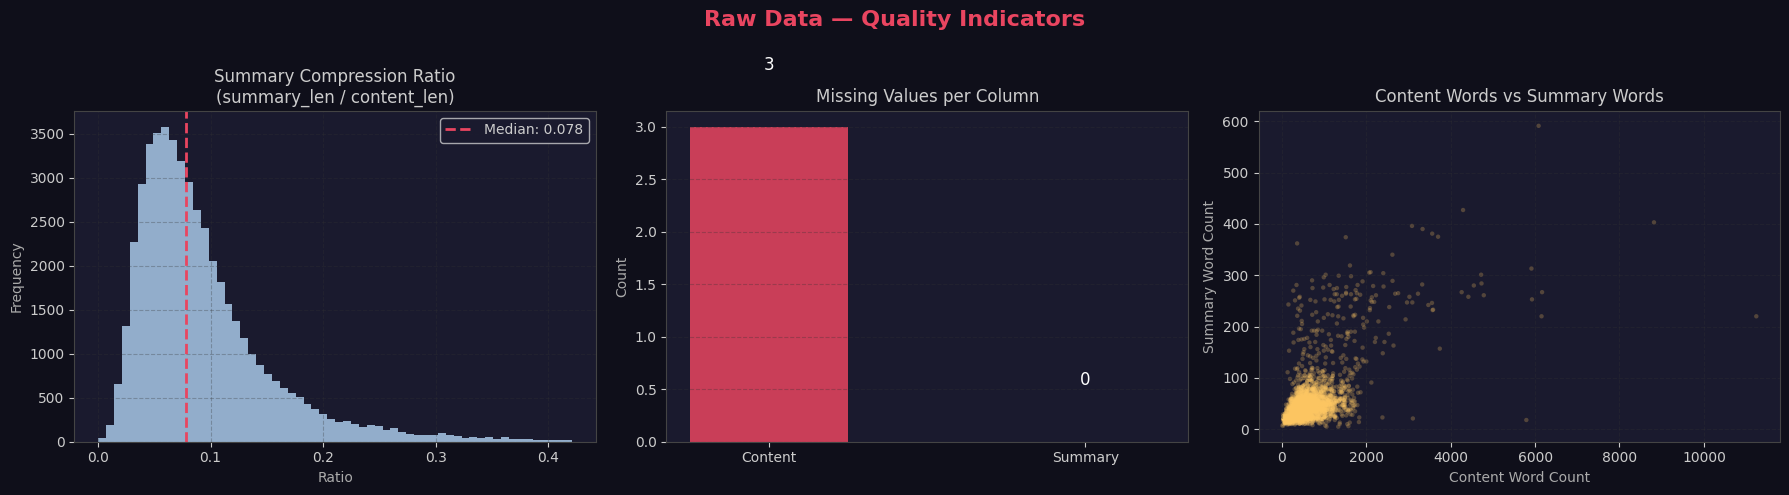

Figure 2 saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Raw Data — Quality Indicators', fontsize=16, color='#e94560', fontweight='bold')

valid_ratio = df['compression_ratio'].replace([np.inf, -np.inf], np.nan).dropna()
valid_ratio = valid_ratio[valid_ratio < valid_ratio.quantile(0.99)]
axes[0].hist(valid_ratio, bins=60, color='#a8c8e8', alpha=0.85, edgecolor='none')
axes[0].axvline(valid_ratio.median(), color='#e94560', linestyle='--', linewidth=2,
                label=f'Median: {valid_ratio.median():.3f}')
axes[0].set_title('Summary Compression Ratio\n(summary_len / content_len)', color='#ccc')
axes[0].set_xlabel('Ratio', color='#aaa')
axes[0].set_ylabel('Frequency', color='#aaa')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

null_counts = df[['Content', 'Summary']].isna().sum()
bars = axes[1].bar(null_counts.index, null_counts.values,
                   color=['#e94560', '#64c896'], width=0.5, alpha=0.85)
axes[1].set_title('Missing Values per Column', color='#ccc')
axes[1].set_ylabel('Count', color='#aaa')
for bar, val in zip(bars, null_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', color='white', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

sample = df.sample(min(3000, len(df)), random_state=42)
axes[2].scatter(sample['content_word_cnt'], sample['summary_word_cnt'],
                alpha=0.25, s=10, color='#ffc864', edgecolors='none')
axes[2].set_title('Content Words vs Summary Words', color='#ccc')
axes[2].set_xlabel('Content Word Count', color='#aaa')
axes[2].set_ylabel('Summary Word Count', color='#aaa')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_quality_indicators.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Figure 2 saved.")

---

##  Part 3 — Preprocessing Pipeline


### 3.1 — Data Cleaning

Drop rows with null values, remove exact-duplicate articles, and filter out samples shorter than the minimum character threshold.


In [8]:
MIN_CONTENT_LENGTH = 100

stage_counts = {'raw': len(df)}

df.dropna(subset=['Content', 'Summary'], inplace=True)
stage_counts['after_null_drop'] = len(df)

df.drop_duplicates(subset=['Content'], inplace=True)
stage_counts['after_dedup'] = len(df)

df = df[df['Content'].str.len() >= MIN_CONTENT_LENGTH]
df.reset_index(drop=True, inplace=True)
stage_counts['after_length_filter'] = len(df)

print(f"  Raw records              : {stage_counts['raw']:,}")
print(f"  After null removal       : {stage_counts['after_null_drop']:,}  (-{stage_counts['raw'] - stage_counts['after_null_drop']:,})")
print(f"  After deduplication      : {stage_counts['after_dedup']:,}  (-{stage_counts['after_null_drop'] - stage_counts['after_dedup']:,})")
print(f"  After length filter      : {stage_counts['after_length_filter']:,}  (-{stage_counts['after_dedup'] - stage_counts['after_length_filter']:,})")
print(f"  Total removed            : {stage_counts['raw'] - stage_counts['after_length_filter']:,}")
print(f"  Retention rate           : {stage_counts['after_length_filter'] / stage_counts['raw'] * 100:.1f}%")

  Raw records              : 50,000
  After null removal       : 49,997  (-3)
  After deduplication      : 48,943  (-1,054)
  After length filter      : 48,930  (-13)
  Total removed            : 1,070
  Retention rate           : 97.9%


### 3.2 — Text Normalization

Normalize the `Content` column for TF-IDF processing (lowercase, strip URLs, remove non-alphabetic characters). The original text is left untouched — BART performs best on clean, unmodified prose.


In [9]:
def clean_text(text: str) -> str:
    """Normalize text for TF-IDF processing.

    Steps
    -----
    1. Lowercase
    2. Strip URLs
    3. Remove non-alphabetic characters
    4. Collapse whitespace
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['Content_Clean'] = df['Content'].apply(clean_text)

print("Before:", df['Content'].iloc[0][:150])
print()
print("After :", df['Content_Clean'].iloc[0][:150])

Before: New York police are concerned drones could become tools for terrorists, and are investigating ways to stop potential attacks. Until now police haven't

After : new york police are concerned drones could become tools for terrorists and are investigating ways to stop potential attacks until now police havent ac


### 3.3 — Train / Test Split

Split the cleaned dataset 80/20 with a fixed random seed so results are fully reproducible across runs.


In [10]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

print(f"Training samples : {len(train_df):,}  ({len(train_df)/len(df)*100:.1f}%)")
print(f"Test samples     : {len(test_df):,}  ({len(test_df)/len(df)*100:.1f}%)")

Training samples : 39,144  (80.0%)
Test samples     : 9,786  (20.0%)


### 3.4 — Post-Preprocessing Visualizations

Compare data quality metrics **before** and **after** the preprocessing pipeline to verify the cleaning steps are working as intended.


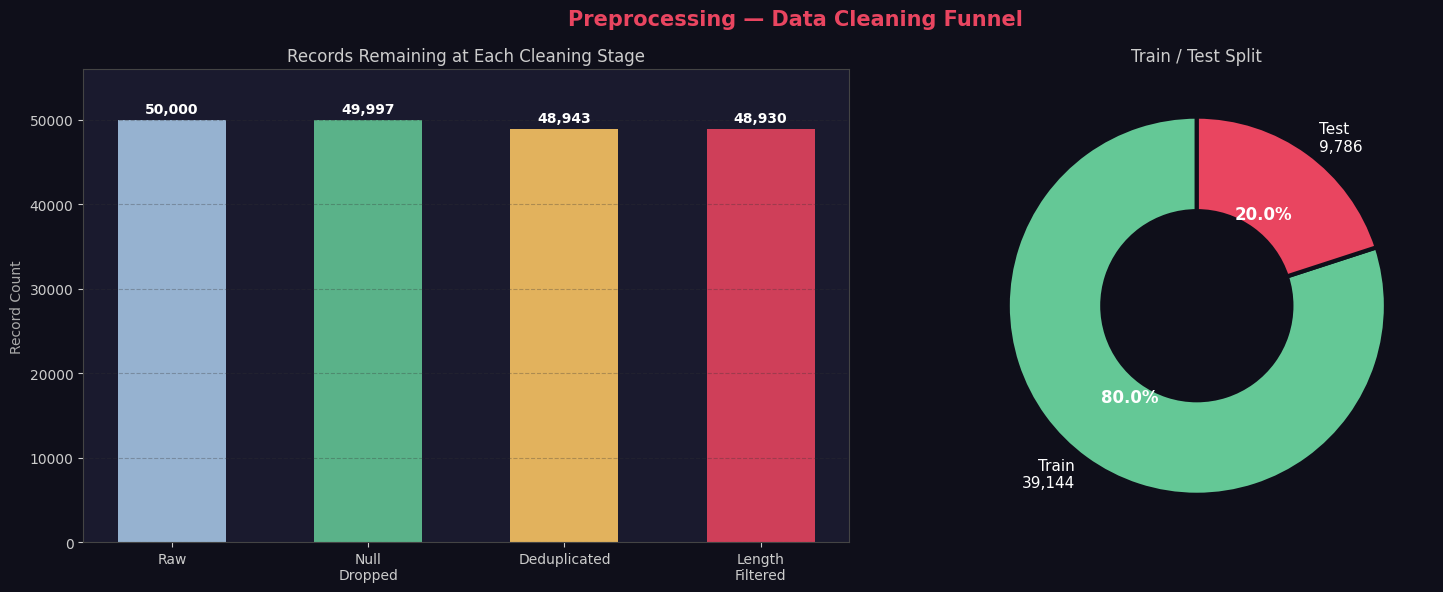

Figure 3 saved.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Preprocessing — Data Cleaning Funnel', fontsize=15, color='#e94560', fontweight='bold')

stages = ['Raw', 'Null\nDropped', 'Deduplicated', 'Length\nFiltered']
counts = list(stage_counts.values())
colors_bar = ['#a8c8e8', '#64c896', '#ffc864', '#e94560']

bars = axes[0].bar(stages, counts, color=colors_bar, width=0.55, alpha=0.88, edgecolor='none')
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(counts) * 0.01,
                 f'{cnt:,}', ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')
axes[0].set_title('Records Remaining at Each Cleaning Stage', color='#ccc')
axes[0].set_ylabel('Record Count', color='#aaa')
axes[0].set_ylim(0, max(counts) * 1.12)
axes[0].grid(True, alpha=0.3, axis='y')

sizes  = [len(train_df), len(test_df)]
labels = [f'Train\n{len(train_df):,}', f'Test\n{len(test_df):,}']
wedge_colors = ['#64c896', '#e94560']
wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels, colors=wedge_colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='#0f0f1a', linewidth=3),
    textprops={'color': 'white', 'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Train / Test Split', color='#ccc')

plt.tight_layout()
plt.savefig('fig3_preprocessing_funnel.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Figure 3 saved.")

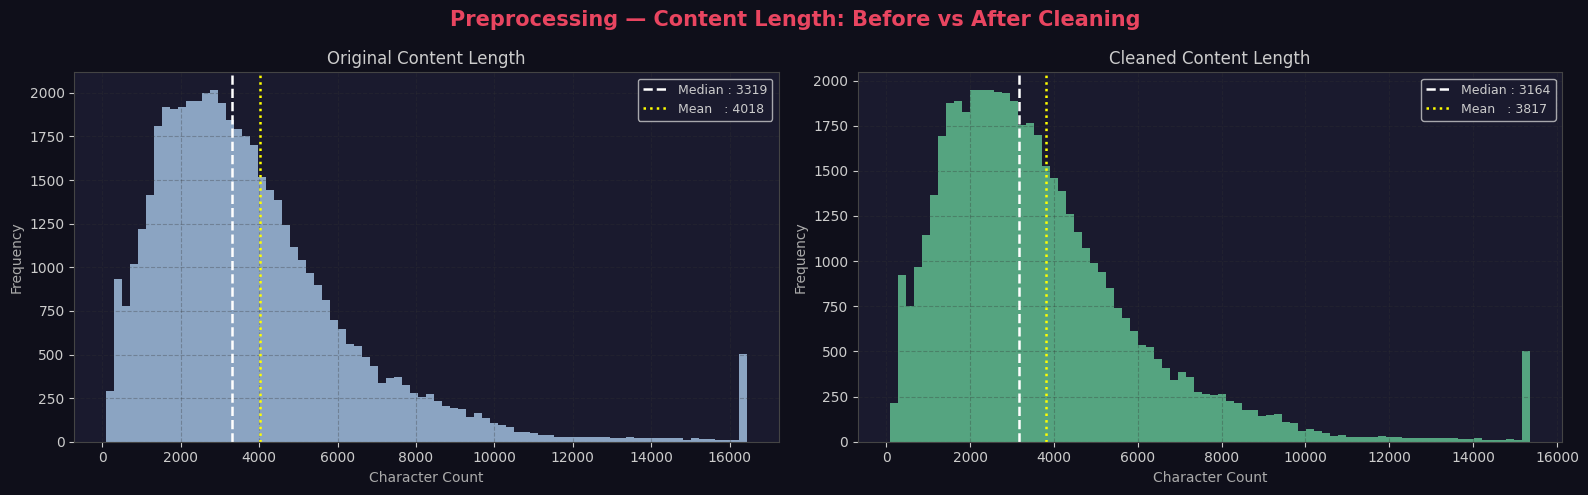

Figure 4 saved.


In [12]:
df['clean_char_len'] = df['Content_Clean'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Preprocessing — Content Length: Before vs After Cleaning', fontsize=15,
             color='#e94560', fontweight='bold')

for ax, col, color, title in [
    (axes[0], 'content_char_len', '#a8c8e8', 'Original Content Length'),
    (axes[1], 'clean_char_len',   '#64c896', 'Cleaned Content Length'),
]:
    series = df[col].clip(upper=df[col].quantile(0.99))
    ax.hist(series, bins=80, color=color, alpha=0.80, edgecolor='none')
    ax.axvline(df[col].median(), color='white',  linestyle='--', linewidth=1.8,
               label=f'Median : {df[col].median():.0f}')
    ax.axvline(df[col].mean(),   color='yellow', linestyle=':',  linewidth=1.8,
               label=f'Mean   : {df[col].mean():.0f}')
    ax.set_title(title, color='#ccc')
    ax.set_xlabel('Character Count', color='#aaa')
    ax.set_ylabel('Frequency', color='#aaa')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_before_after_lengths.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Figure 4 saved.")

---

##  Part 4 — TF-IDF Extractive Summarization

Extractive summarization ranks each sentence by its TF-IDF score and returns the top-N sentences in their original order, preserving document coherence.


### 4.1 — Model Definition

Define the TF-IDF summarization function. It tokenizes the document into sentences, scores each one by its mean TF-IDF weight, and returns the top-ranked sentences in their original order.


In [13]:
def tfidf_summary(text: str, n_sentences: int = 3) -> str:
    """Generate an extractive summary using TF-IDF sentence ranking.

    Parameters
    ----------
    text        : str — Input document.
    n_sentences : int — Number of top-ranked sentences to include.

    Returns
    -------
    str — Extracted summary in original sentence order.
    """
    sentences = sent_tokenize(text)

    if len(sentences) <= n_sentences:
        return text

    vectorizer      = TfidfVectorizer(stop_words='english')
    tfidf_matrix    = vectorizer.fit_transform(sentences)
    sentence_scores = np.array(tfidf_matrix.mean(axis=1)).flatten()
    top_indices     = sorted(np.argsort(sentence_scores)[-n_sentences:])

    return ' '.join([sentences[i] for i in top_indices])

### 4.2 — Training Phase

Fit the TF-IDF vectorizer on the training corpus to learn vocabulary and IDF weights. Bigrams are included alongside unigrams to capture multi-word phrases.


In [14]:
print("Training TF-IDF vectorizer on training corpus...")

tfidf_train_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=50_000,
    ngram_range=(1, 2)
)
tfidf_train_vectorizer.fit(train_df['Content_Clean'])

vocab_size = len(tfidf_train_vectorizer.vocabulary_)
print(f"Vocabulary size : {vocab_size:,} tokens")
print(f"Training docs  : {len(train_df):,}")

feature_names = tfidf_train_vectorizer.get_feature_names_out()
idf_vals      = tfidf_train_vectorizer.idf_
top_idx       = np.argsort(idf_vals)[-20:]

print("\n--- Top 20 High-IDF (Distinctive) Terms ---")
for term, score in zip(feature_names[top_idx][::-1], idf_vals[top_idx][::-1]):
    print(f"  {term:<30} idf={score:.3f}")

Training TF-IDF vectorizer on training corpus...
Vocabulary size : 50,000 tokens
Training docs  : 39,144

--- Top 20 High-IDF (Distinctive) Terms ---
  cubs vs                        idf=10.882
  hurricane florence             idf=10.882
  shown reflect                  idf=10.882
  photographer euless            idf=10.882
  perone                         idf=10.882
  cypress saturday               idf=10.882
  series cubs                    idf=10.882
  shall sentenced                idf=10.882
  tomballs karlie                idf=10.882
  tomballs                       idf=10.882
  usa saturday                   idf=10.882
  photos unrest                  idf=10.882
  photos free                    idf=10.882
  arab bank                      idf=10.882
  photos crisis                  idf=10.882
  apollo archive                 idf=10.882
  ping mei                       idf=10.882
  listed chemical                idf=10.882
  phq                            idf=10.882
  weight point

### 4.3 — Inference on Test Set

Run a quick demo on one sample, then apply the TF-IDF summarizer to the entire test set.


In [15]:
sample_text  = test_df['Content'].iloc[0]
tfidf_result = tfidf_summary(sample_text, n_sentences=3)

print("=" * 60)
print("  SAMPLE DEMO — TF-IDF")
print("=" * 60)
print("\n Original Text (first 400 chars):")
print(sample_text[:400])
print("\n TF-IDF Extractive Summary:")
print(tfidf_result)
print("\n Reference Summary:")
print(test_df['Summary'].iloc[0])

  SAMPLE DEMO — TF-IDF

 Original Text (first 400 chars):
After a rain-delayed start, an innings-best partnership of 91 between Will Smith (93) and Gareth Berg (50) carried the hosts' score past 400.
Neil Dexter claimed four of the five wickets to fall in the day with his medium pace to achieve figures of 5-64.
Joe Burns (38) edged the penultimate ball of the day behind to leave Middlesex 102-3, still 311 runs behind.
Rain meant that play got under way a

 TF-IDF Extractive Summary:
Rain meant that play got under way at 14:15 BST and Hampshire lost Sean Ervine early on when he was bowled by Toby Roland-Jones after adding just one run. Hampshire began brightly with the ball and debutant Brad Wheal produced a quick delivery which nipped back to bowl Sam Robson, before Edwards struck with his first delivery to pin Nick Gubbins lbw. The away side appeared to have weathered the early pressure but with the partnership worth 69 runs and Nick Compton 32 not out, Burns edged Ervine to Adam Whea

In [16]:
print("Generating TF-IDF summaries for all test samples...")
test_df['TF-IDF_Summary'] = test_df['Content'].apply(
    lambda x: tfidf_summary(x, n_sentences=3)
)
print(f"TF-IDF summaries generated for {len(test_df):,} test samples.")

Generating TF-IDF summaries for all test samples...
TF-IDF summaries generated for 9,786 test samples.


---

## Part 5 — BART Abstractive Summarization

The `facebook/bart-large-cnn` model generates novel summaries that may rephrase or compress the source text. Raw unprocessed text is passed as input, since BART was fine-tuned on natural-language prose.


### 5.1 — Model Loading

Download and load the `facebook/bart-large-cnn` model and tokenizer. The model is set to eval mode to disable dropout for deterministic inference.


In [17]:
BART_MODEL_NAME = 'facebook/bart-large-cnn'

print(f"Loading: {BART_MODEL_NAME} ...")
bart_tokenizer = BartTokenizer.from_pretrained(BART_MODEL_NAME)
bart_model     = BartForConditionalGeneration.from_pretrained(BART_MODEL_NAME)
bart_model.eval()
print(f"Model loaded. Parameters: {sum(p.numel() for p in bart_model.parameters()):,}")

Loading: facebook/bart-large-cnn ...


[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 
Loading weights: 100%|██████████| 511/511 [00:00<00:00, 2782.83it/s]


Model loaded. Parameters: 406,290,432


### 5.2 — Inference Function

Wrap the BART model in a clean function. Input text is tokenized and truncated to 1024 tokens. Summaries are generated using beam search.


In [18]:
def bart_summary(
    text: str,
    max_input_length:  int = 1024,
    max_output_length: int = 150,
    min_output_length: int = 40,
    num_beams:         int = 4
) -> str:
    """Generate an abstractive summary using the BART-large-CNN model.

    Parameters
    ----------
    text              : str — Input document (unmodified natural language).
    max_input_length  : int — Maximum encoder token length (default 1024).
    max_output_length : int — Maximum decoder output tokens (default 150).
    min_output_length : int — Minimum decoder output tokens (default 40).
    num_beams         : int — Beam search width (default 4).

    Returns
    -------
    str — Abstractive summary.
    """
    inputs = bart_tokenizer(
        text,
        return_tensors='pt',
        max_length=max_input_length,
        truncation=True
    )

    with torch.no_grad():
        summary_ids = bart_model.generate(
            inputs['input_ids'],
            max_length=max_output_length,
            min_length=min_output_length,
            num_beams=num_beams,
            length_penalty=2.0,
            early_stopping=True
        )

    return bart_tokenizer.decode(summary_ids[0], skip_special_tokens=True)

### 5.3 — Sample Demonstration

Run BART on the same sample used in the TF-IDF demo, so we can compare outputs side by side.


In [19]:
bart_result = bart_summary(sample_text)

print("=" * 60)
print("  SAMPLE DEMO — BART")
print("=" * 60)
print("\nOriginal Text (first 400 chars):")
print(sample_text[:400])
print("\nBART Abstractive Summary:")
print(bart_result)
print("\nReference Summary:")
print(test_df['Summary'].iloc[0])

  SAMPLE DEMO — BART

Original Text (first 400 chars):
After a rain-delayed start, an innings-best partnership of 91 between Will Smith (93) and Gareth Berg (50) carried the hosts' score past 400.
Neil Dexter claimed four of the five wickets to fall in the day with his medium pace to achieve figures of 5-64.
Joe Burns (38) edged the penultimate ball of the day behind to leave Middlesex 102-3, still 311 runs behind.
Rain meant that play got under way a

BART Abstractive Summary:
Neil Dexter claimed four of the five wickets to fall in the day with his medium pace. Will Smith (93) and Gareth Berg (50) carried the hosts' score past 400. Joe Burns (38) edged the penultimate ball of the day behind to leave Middlesex 102-3.

Reference Summary:
Division One table-toppers Middlesex endured a difficult second day against Hampshire at the Ageas Bowl.


### 5.4 — Evaluation Subset Inference

Due to CPU runtime constraints, BART inference is limited to 100 samples. These are used for all ROUGE and classification evaluation in Part 6.


In [20]:
EVAL_SAMPLE_SIZE        = 100
eval_df                 = test_df.head(EVAL_SAMPLE_SIZE).copy()

print(f"Generating BART summaries for {EVAL_SAMPLE_SIZE} evaluation samples...")
eval_df['BART_Summary'] = eval_df['Content'].apply(bart_summary)
print(f"BART summaries generated for {EVAL_SAMPLE_SIZE} samples.")

Generating BART summaries for 100 evaluation samples...
BART summaries generated for 100 samples.


---

##  Part 6 — Evaluation

Summarization quality is measured using **ROUGE** scores (n-gram overlap between generated and reference summaries). We also apply a binary quality-bucketing step to evaluate agreement between TF-IDF and BART using a confusion matrix and classification report.


### 6.1 — ROUGE Score Computation

Compute ROUGE-1, ROUGE-2, and ROUGE-L F1 scores for both models against the reference summaries. Results are averaged across the evaluation subset.


In [21]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def compute_rouge(predictions: pd.Series, references: pd.Series) -> pd.DataFrame:
    """Compute ROUGE-1, ROUGE-2, and ROUGE-L F1 scores.

    Parameters
    ----------
    predictions : pd.Series — Generated summaries.
    references  : pd.Series — Reference (ground truth) summaries.

    Returns
    -------
    pd.DataFrame — Per-sample ROUGE scores.
    """
    rows = []
    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)
        rows.append({
            'rouge1': scores['rouge1'].fmeasure,
            'rouge2': scores['rouge2'].fmeasure,
            'rougeL': scores['rougeL'].fmeasure,
        })
    return pd.DataFrame(rows)


tfidf_rouge = compute_rouge(
    eval_df['TF-IDF_Summary'],
    eval_df['Summary']
)

bart_rouge = compute_rouge(
    eval_df['BART_Summary'],
    eval_df['Summary']
)

rouge_summary = pd.DataFrame({
    'TF-IDF': tfidf_rouge.mean(),
    'BART':   bart_rouge.mean()
}).round(4)

print("=" * 40)
print("  ROUGE SCORES (Mean F1 over eval set)")
print("=" * 40)
print(rouge_summary.to_string())
print("=" * 40)

  ROUGE SCORES (Mean F1 over eval set)
        TF-IDF    BART
rouge1  0.2545  0.3559
rouge2  0.0778  0.1534
rougeL  0.1547  0.2489


### 6.2 — ROUGE Score Visualization

Plot histograms of per-sample ROUGE distributions and a grouped bar chart comparing mean scores across both models.


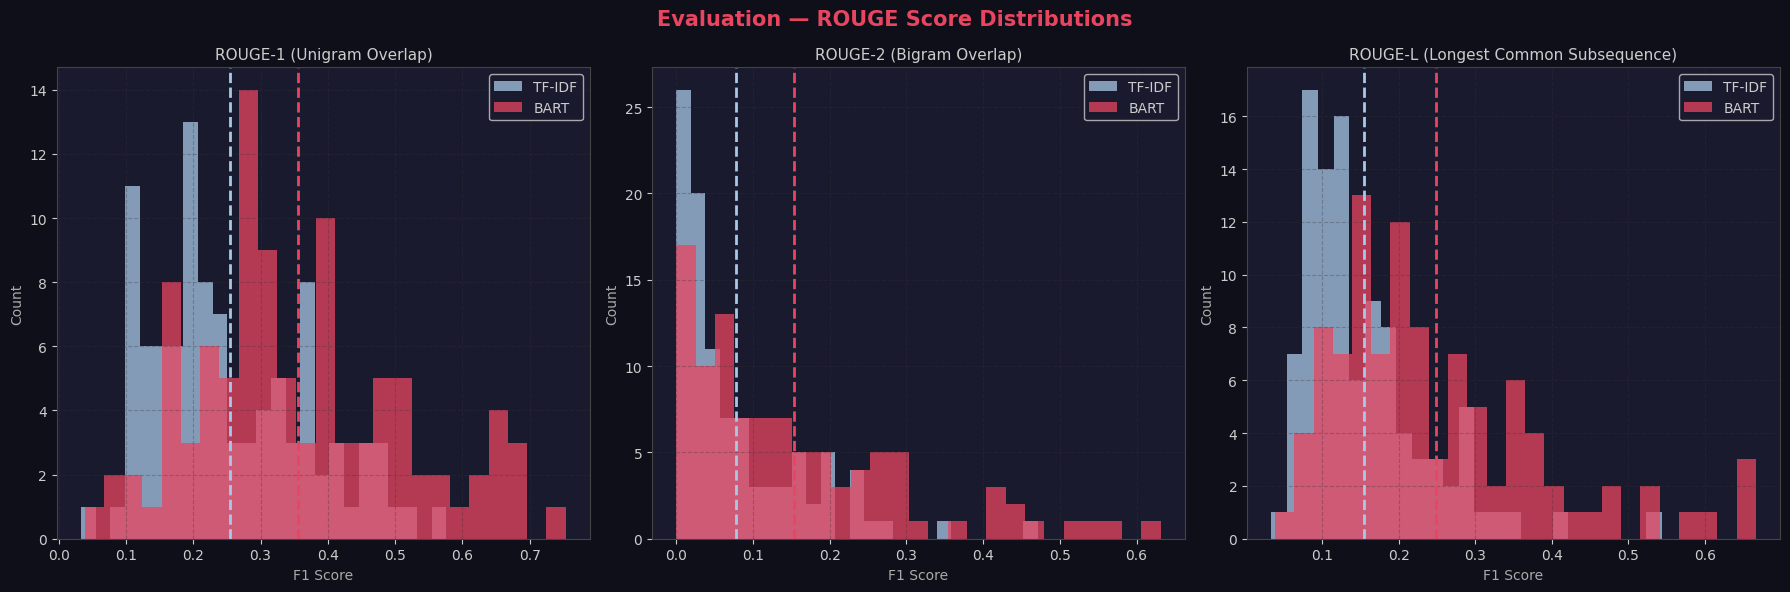

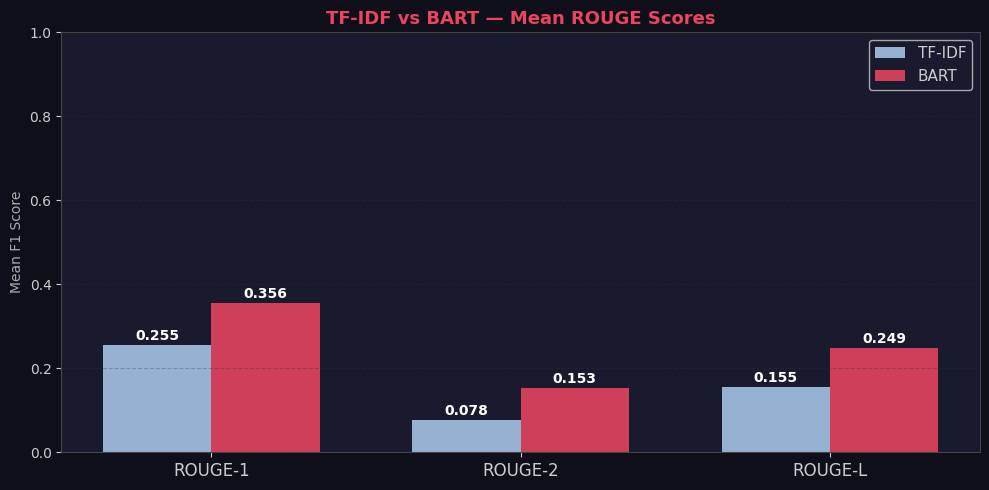

Figures 5 & 6 saved.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Evaluation — ROUGE Score Distributions', fontsize=15, color='#e94560', fontweight='bold')

metrics = ['rouge1', 'rouge2', 'rougeL']
titles  = ['ROUGE-1 (Unigram Overlap)', 'ROUGE-2 (Bigram Overlap)', 'ROUGE-L (Longest Common Subsequence)']

for ax, metric, title in zip(axes, metrics, titles):
    ax.hist(tfidf_rouge[metric], bins=25, alpha=0.75, color='#a8c8e8', label='TF-IDF', edgecolor='none')
    ax.hist(bart_rouge[metric],  bins=25, alpha=0.75, color='#e94560', label='BART',   edgecolor='none')
    ax.axvline(tfidf_rouge[metric].mean(), color='#a8c8e8', linestyle='--', linewidth=2)
    ax.axvline(bart_rouge[metric].mean(),  color='#e94560', linestyle='--', linewidth=2)
    ax.set_title(title, color='#ccc', fontsize=11)
    ax.set_xlabel('F1 Score', color='#aaa')
    ax.set_ylabel('Count', color='#aaa')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_rouge_distributions.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(metrics))
width  = 0.35

b1 = ax.bar(x - width/2, rouge_summary['TF-IDF'], width, color='#a8c8e8', alpha=0.88, label='TF-IDF')
b2 = ax.bar(x + width/2, rouge_summary['BART'],   width, color='#e94560', alpha=0.88, label='BART')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}',
            ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['ROUGE-1', 'ROUGE-2', 'ROUGE-L'], fontsize=12)
ax.set_ylabel('Mean F1 Score', color='#aaa')
ax.set_title('TF-IDF vs BART — Mean ROUGE Scores', color='#e94560', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig6_rouge_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Figures 5 & 6 saved.")

### 6.3 — Quality Bucketing for Classification Evaluation

To use standard classification metrics, ROUGE-L F1 scores are binarized into **High Quality** (≥ 0.4) and **Low Quality** (< 0.4) labels. BART serves as the ground truth and TF-IDF as the predicted label.


In [23]:
QUALITY_THRESHOLD = 0.4


y_true = (bart_rouge['rougeL']  >= QUALITY_THRESHOLD).astype(int)
y_pred = (tfidf_rouge['rougeL'] >= QUALITY_THRESHOLD).astype(int)

label_names = ['Low Quality', 'High Quality']

print(f"Quality threshold (ROUGE-L F1) : {QUALITY_THRESHOLD}")
print(f"High quality (BART)    : {y_true.sum()} / {len(y_true)}")
print(f"High quality (TF-IDF)  : {y_pred.sum()} / {len(y_pred)}")

Quality threshold (ROUGE-L F1) : 0.4
High quality (BART)    : 12 / 100
High quality (TF-IDF)  : 2 / 100


### 6.4 — Confusion Matrix

Visualize how often TF-IDF's quality label agrees with BART's on the evaluation set.


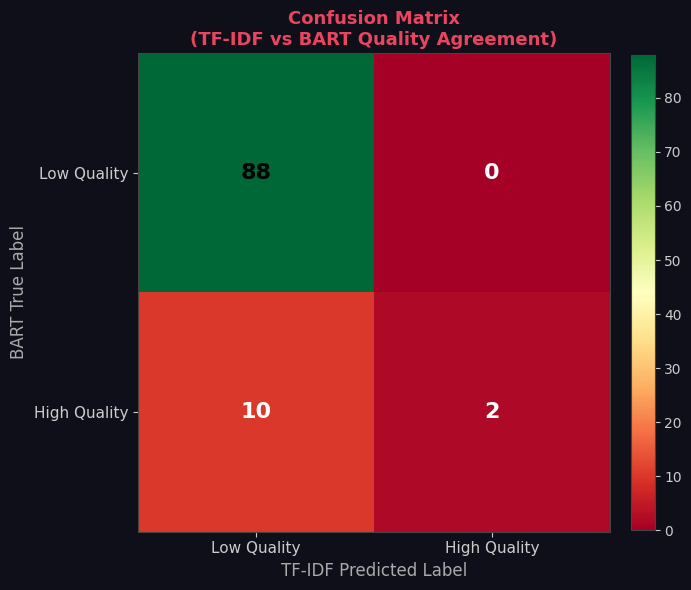

Figure 7 saved.


In [24]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

im = ax.imshow(cm, interpolation='nearest', cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='black' if cm[i, j] > thresh else 'white',
                fontsize=16, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(label_names, color='#ccc', fontsize=11)
ax.set_yticklabels(label_names, color='#ccc', fontsize=11)
ax.set_xlabel('TF-IDF Predicted Label', color='#aaa', fontsize=12)
ax.set_ylabel('BART True Label', color='#aaa', fontsize=12)
ax.set_title('Confusion Matrix\n(TF-IDF vs BART Quality Agreement)', color='#e94560', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig7_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Figure 7 saved.")

### 6.5 — Classification Report

Print precision, recall, and F1-score for both quality classes.


In [25]:
report = classification_report(y_true, y_pred, target_names=label_names)

print("=" * 55)
print("  CLASSIFICATION REPORT")
print("  (TF-IDF Quality Agreement with BART)")
print("=" * 55)
print(report)

  CLASSIFICATION REPORT
  (TF-IDF Quality Agreement with BART)
              precision    recall  f1-score   support

 Low Quality       0.90      1.00      0.95        88
High Quality       1.00      0.17      0.29        12

    accuracy                           0.90       100
   macro avg       0.95      0.58      0.62       100
weighted avg       0.91      0.90      0.87       100



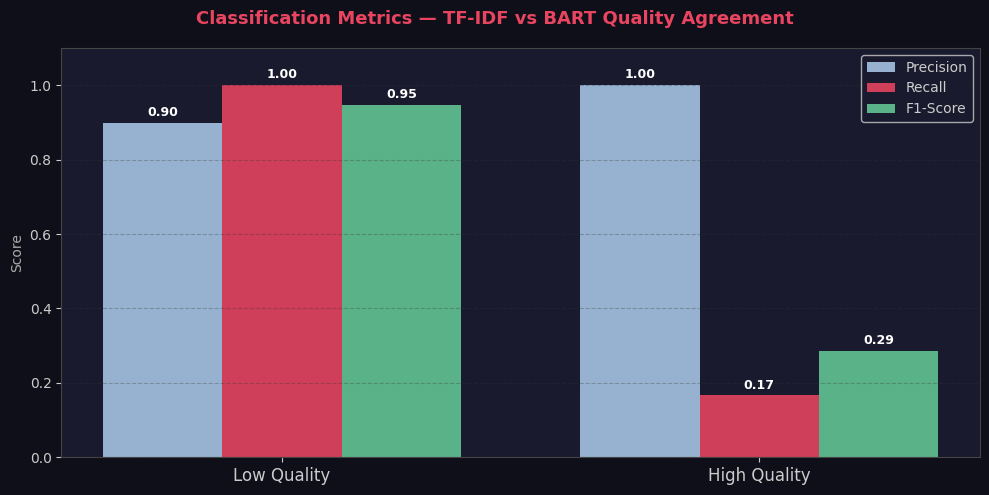

Figure 8 saved.


In [26]:
from sklearn.metrics import classification_report as cr
report_dict = cr(y_true, y_pred, target_names=label_names, output_dict=True)

metrics_df = pd.DataFrame(report_dict).T
metrics_df = metrics_df.drop(columns=['support'], errors='ignore')
metrics_df = metrics_df.loc[label_names]

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Classification Metrics — TF-IDF vs BART Quality Agreement',
             fontsize=13, color='#e94560', fontweight='bold')

x = np.arange(len(metrics_df))
w = 0.25
colors = ['#a8c8e8', '#e94560', '#64c896']
cols   = ['precision', 'recall', 'f1-score']
labels = ['Precision', 'Recall', 'F1-Score']

for i, (col, label, color) in enumerate(zip(cols, labels, colors)):
    bars = ax.bar(x + (i - 1) * w, metrics_df[col], w, label=label, color=color, alpha=0.88, edgecolor='none')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
                ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(label_names, fontsize=12)
ax.set_ylabel('Score', color='#aaa')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig8_classification_metrics.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Figure 8 saved.")

---

##  Part 7 — Unified Pipeline

A single `summarize_text` function wraps both approaches behind a consistent interface.


In [27]:
def summarize_text(text: str, method: str = 'bart') -> str:
    """Unified summarization interface.

    Parameters
    ----------
    text   : str — Input document.
    method : str — 'tfidf' (extractive) | 'bart' (abstractive).

    Returns
    -------
    str — Generated summary.

    Raises
    ------
    ValueError — If input is empty or method is unrecognized.
    """
    if not isinstance(text, str) or not text.strip():
        raise ValueError("Input text must be a non-empty string.")

    method = method.lower().strip()

    if method == 'tfidf':
        return tfidf_summary(text, n_sentences=3)
    elif method == 'bart':
        return bart_summary(text)
    else:
        raise ValueError(f"Unknown method '{method}'. Choose 'tfidf' or 'bart'.")

In [28]:
test_input = test_df['Content'].iloc[1]

print(" Original Text:")
print(test_input[:300], "...")

print("\n TF-IDF via Pipeline:")
print(summarize_text(test_input, method='tfidf'))

print("\n BART via Pipeline:")
print(summarize_text(test_input, method='bart'))

 Original Text:
By . Sam Webb for MailOnline . A man who paid a drug addict just £1,000 to kill his wife because he was having an affair with her sister was convicted has been convicted of murder. Mother-of-two Amina Bibi was stabbed at least 70 times in the attack at the couple's flat in Forest Gate, east London.  ...

 TF-IDF via Pipeline:
Husband Mohamed Ali, 65, was heavily in debt and having an affair with his sister-in-law in Pakistan when he approached drug addict Frederick Best, 47. Detective Chief Inspector Dave Whellams, of the Homicide and Major Crime Command, said: 'This was a cold and calculated act planned and devised by Mohamed Ali to have the mother of his two sons killed. 'He also gave Best a key to his front door to gain entry to the flat while Ali used the 'school run' to provide himself with an alibi, secure in the knowledge that his unsuspecting wife was at home alone.

 BART via Pipeline:
Mother-of-two Amina Bibi was stabbed at least 70 times. Her 11-year-old son 

---

## Part 8 — Prediction on Test Set

Full test-set inference using both pipelines. Results are exported to a CSV file for downstream use.


In [29]:
predictions_df = eval_df[['Content', 'Summary', 'TF-IDF_Summary', 'BART_Summary']].copy()
predictions_df.columns = ['Original_Content', 'Reference_Summary', 'TF_IDF_Prediction', 'BART_Prediction']

print(f" Predictions captured for {len(predictions_df)} test samples.")
print()
predictions_df.head(3)

 Predictions captured for 100 test samples.



,Original_Content,Reference_Summary,TF_IDF_Prediction,BART_Prediction
0,"After a rain-delayed start, an innings-best pa...",Division One table-toppers Middlesex endured a...,Rain meant that play got under way at 14:15 BS...,Neil Dexter claimed four of the five wickets t...
1,By . Sam Webb for MailOnline . A man who paid ...,Mother-of-two Amina Bibi was stabbed at least ...,"Husband Mohamed Ali, 65, was heavily in debt a...",Mother-of-two Amina Bibi was stabbed at least ...
2,(CNN) -- The Afghan government says armed indi...,"NEW: ""Such actions have caused local public re...",(CNN) -- The Afghan government says armed indi...,NEW: The U.S. military says it is investigatin...


In [30]:
OUTPUT_PATH = 'predictions_output.csv'
predictions_df.to_csv(OUTPUT_PATH, index=False)
print(f" Predictions exported to: {OUTPUT_PATH}")
print(f"   Rows     : {len(predictions_df):,}")
print(f"   Columns  : {predictions_df.columns.tolist()}")

 Predictions exported to: predictions_output.csv
   Rows     : 100
   Columns  : ['Original_Content', 'Reference_Summary', 'TF_IDF_Prediction', 'BART_Prediction']


---

##  Part 9 — Summary & Conclusions


In [31]:
print("=" * 65)
print("  FINAL RESULTS SUMMARY")
print("=" * 65)
print()
print("  ROUGE Scores (Mean F1 — Evaluation Subset)")
print(f"  {'Metric':<12} {'TF-IDF':>10} {'BART':>10}")
print("  " + "-" * 35)
for metric in ['rouge1', 'rouge2', 'rougeL']:
    tfidf_val = tfidf_rouge[metric].mean()
    bart_val  = bart_rouge[metric].mean()
    winner    = 'TF-IDF' if tfidf_val > bart_val else 'BART  '
    print(f"  {metric.upper():<12} {tfidf_val:>10.4f} {bart_val:>10.4f}   ← {winner}")
print()
print("  Classification Report (Quality Agreement)")
print(f"  Quality threshold : ROUGE-L ≥ {QUALITY_THRESHOLD}")
print(report)
print("=" * 65)

  FINAL RESULTS SUMMARY

  ROUGE Scores (Mean F1 — Evaluation Subset)
  Metric           TF-IDF       BART
  -----------------------------------
  ROUGE1           0.2545     0.3559   ← BART  
  ROUGE2           0.0778     0.1534   ← BART  
  ROUGEL           0.1547     0.2489   ← BART  

  Classification Report (Quality Agreement)
  Quality threshold : ROUGE-L ≥ 0.4
              precision    recall  f1-score   support

 Low Quality       0.90      1.00      0.95        88
High Quality       1.00      0.17      0.29        12

    accuracy                           0.90       100
   macro avg       0.95      0.58      0.62       100
weighted avg       0.91      0.90      0.87       100



### Key Takeaways

| Dimension | TF-IDF (Extractive) | BART (Abstractive) |
|---|---|---|
| **Speed** |  Very fast (milliseconds per doc) |  Slow (seconds per doc on CPU) |
| **Faithfulness** |  Always uses original sentences |  May hallucinate details |
| **Fluency** |  Sentence-level coherence only |  Naturally fluent prose |
| **Compression** |  Limited — only selects existing text |  True compression possible |
| **Resource use** |  CPU, minimal memory |  Large model (~1.6 GB) |
| **Best for** | Long technical documents | News, general prose |

